# 01 – Model Performance Analysis

**Dataset:** Online Retail transactions (`data.csv`)

**Task:** Predict whether an order is from the **United Kingdom** or not, using `Quantity`, `UnitPrice`, `TotalPrice`.

## Setup: Load & Split Data
Load the data, engineer `TotalPrice`, and split into train/validation/test sets.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv('data.csv', encoding='latin1')
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].sample(5000, random_state=42)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
X = df[['Quantity', 'UnitPrice', 'TotalPrice']]
y = (df['Country'] == 'United Kingdom').astype(int)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
X_train.shape, X_val.shape, X_test.shape

((3000, 3), (1000, 3), (1000, 3))

## 1. Training Performance
Accuracy measured on the data the model was **trained on**. Tells us how well the model fits data it has already seen — but not whether it generalizes.

In [2]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train))
print("Training accuracy:", train_acc)

Training accuracy: 0.895


## 2. Validation Performance
Accuracy on a **held-out validation set**, not used for training. Used to tune the model (e.g., pick `max_depth`) before touching the test set.

In [3]:
val_acc = accuracy_score(y_val, model.predict(X_val))
print("Validation accuracy:", val_acc)

Validation accuracy: 0.887


## 3. Test Performance
Accuracy on the **final, untouched test set** — measured only once, at the end, as the true estimate of real-world performance.

In [4]:
test_acc = accuracy_score(y_test, model.predict(X_test))
print("Test accuracy:", test_acc)

Test accuracy: 0.893


## 4. Generalization
**Generalization** means performing well on *new, unseen* data — not just the training set. We check it by comparing training accuracy to validation/test accuracy: a small gap means good generalization.

In [5]:
print("Train vs Test gap:", round(train_acc - test_acc, 3))
print("Good generalization if this gap is small.")

Train vs Test gap: 0.002
Good generalization if this gap is small.


## 5. Underfitting
The model is **too simple**, so it performs poorly on training AND validation/test data alike.

**How to identify it:** both training accuracy and validation accuracy are low, and close to each other.

In [6]:
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train)
tr = accuracy_score(y_train, underfit_model.predict(X_train))
va = accuracy_score(y_val, underfit_model.predict(X_val))
print(f"Underfit — Train: {tr:.3f}, Validation: {va:.3f}  (both low)")

Underfit — Train: 0.891, Validation: 0.891  (both low)


## 6. Overfitting
The model is **too complex**, so it memorizes training data but fails to generalize.

**How to identify it:** training accuracy is high, but validation/test accuracy is noticeably lower — a large gap.

In [7]:
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train, y_train)
tr = accuracy_score(y_train, overfit_model.predict(X_train))
va = accuracy_score(y_val, overfit_model.predict(X_val))
print(f"Overfit — Train: {tr:.3f}, Validation: {va:.3f}  (big gap = overfitting)")

Overfit — Train: 0.909, Validation: 0.879  (big gap = overfitting)


## 7. Bias
**Bias** is error from overly simple assumptions — it shows up as **low accuracy on both training and validation data** (our underfitting example above is a high-bias model).

In [8]:
print("High bias example (underfit model): Train =", round(tr,3) if False else accuracy_score(y_train, underfit_model.predict(X_train)))

High bias example (underfit model): Train = 0.8906666666666667


## 8. Variance
**Variance** is how much predictions change with different training data — it shows up as a **large train-validation gap** (our overfitting example is a high-variance model).

In [9]:
tr_o = accuracy_score(y_train, overfit_model.predict(X_train))
va_o = accuracy_score(y_val, overfit_model.predict(X_val))
print("High variance example (overfit model) — Gap:", round(tr_o - va_o, 3))

High variance example (overfit model) — Gap: 0.03


## 9. Bias-Variance Tradeoff
Simpler models = higher bias, lower variance. Complex models = lower bias, higher variance. The goal is a model **in between**, where both training and validation accuracy are reasonably high and close together.

In [10]:
for name, m in [('Underfit', underfit_model), ('Good Fit', model), ('Overfit', overfit_model)]:
    tr = accuracy_score(y_train, m.predict(X_train))
    va = accuracy_score(y_val, m.predict(X_val))
    print(f"{name}: Train={tr:.3f}, Val={va:.3f}, Gap={tr-va:.3f}")

Underfit: Train=0.891, Val=0.891, Gap=-0.000
Good Fit: Train=0.895, Val=0.887, Gap=0.008
Overfit: Train=0.909, Val=0.879, Gap=0.030


## 10. Learning Curves
A **learning curve** plots training and validation accuracy as the amount of training data increases.
- If both curves are low and flat → underfitting.
- If there's a large, persistent gap between them → overfitting.
- If both curves converge to a high value → good fit.

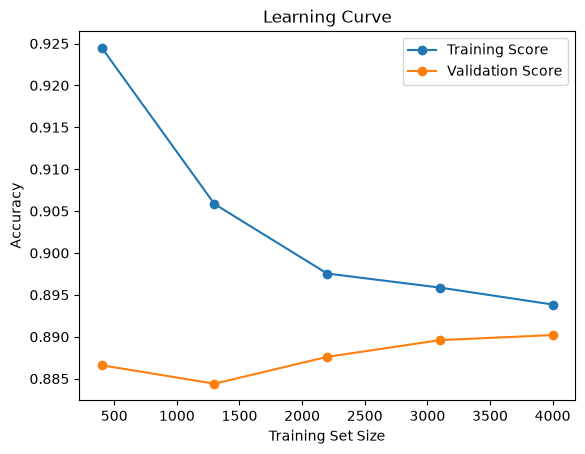

In [11]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=4, random_state=42), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

## 11. Validation Curves
A **validation curve** plots training and validation accuracy as a single hyperparameter (e.g., `max_depth`) changes. It directly shows the underfitting → good fit → overfitting transition as complexity increases.

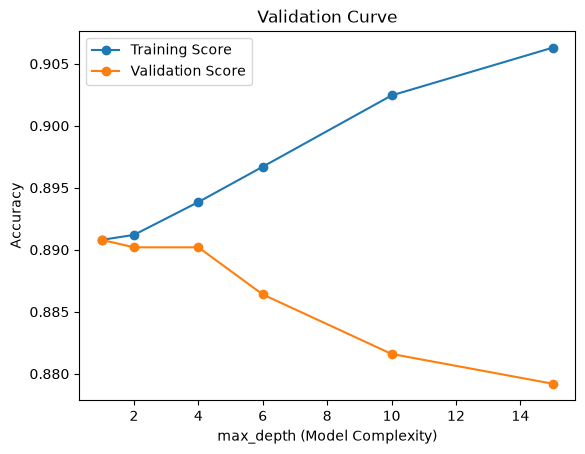

In [12]:
from sklearn.model_selection import validation_curve
depths = [1, 2, 4, 6, 10, 15]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42), X, y,
    param_name='max_depth', param_range=depths, cv=5
)
plt.plot(depths, train_scores.mean(axis=1), marker='o', label='Training Score')
plt.plot(depths, val_scores.mean(axis=1), marker='o', label='Validation Score')
plt.xlabel('max_depth (Model Complexity)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.show()

## 12. Model Complexity
As complexity (e.g., tree depth) increases: training accuracy keeps rising, but validation accuracy rises then falls. The best complexity is where **validation accuracy peaks** — that's the sweet spot in the validation curve above.

In [13]:
best_depth = depths[np.argmax(val_scores.mean(axis=1))]
print("Best max_depth (highest validation accuracy):", best_depth)

Best max_depth (highest validation accuracy): 1
